# 沐曦 GPU 运行 NV-Generate-CT RFlow 说明文档

[NV-Generate-CTMR](https://github.com/NVIDIA-Medtech/NV-Generate-CTMR) 是基于 MAISI 的三维医学影像 latent diffusion 生成项目。本教程在沐曦 GPU 上复现 `rflow-ct` 的四类推理任务：

1. `image`：从随机 latent noise 生成单通道三维合成 CT；
2. `mask`：从随机 latent noise 与 anatomy-size 条件生成 MAISI label-space 三维标签图；
3. `from-mask`：使用本轮 `mask` 输出作为条件生成三维合成 CT；
4. `pair`：独立生成空间配对的三维合成 CT 与局部 ordinal label map。

`mask` 输出中的整数是 MAISI label IDs；`pair` 标签中的 `1..N` 则按本次请求的 anatomy 顺序局部编号，两者不能混用。教程不读取患者影像，不使用 candidate-mask 数据集，也不分发源码、权重或生成的 NIfTI。

上游源代码采用 Apache License 2.0，全文见同目录 `LICENSE`。CT 模型页面指向 [NVIDIA Open Model License](https://www.nvidia.com/en-us/agreements/enterprise-software/nvidia-open-model-license/)，模型权重需由使用者依据发布页面条款自行取得。本教程和所有输出仅用于工程与研究验证，不用于诊断、治疗、分诊、临床决策、患者服务或监管提交。

## 1. 安装

以下命令仅供操作者在 Notebook 外准备环境；Markdown 单元不会执行安装、下载或修改环境。

### 1.1 沐曦容器

先在宿主机准备好上游源码、模型目录和可写输出目录，再启动包含 MACA PyTorch 的基础镜像。源码和模型以只读方式挂载；全部资产就绪后可保持容器禁网。

```bash
docker run -it --name nv-generate-ct-rflow-notebook \
  --device=/dev/mxcd --device=/dev/dri \
  --group-add video --network none \
  --shm-size=16G \
  --ulimit memlock=-1 --ulimit stack=67108864 \
  -v /path/to/NV-Generate-CTMR:/workspace/NV-Generate-CTMR:ro \
  -v /path/to/NV-Generate-CT:/workspace/models/NV-Generate-CT:ro \
  -v /path/to/output:/workspace/output \
  <MACA_PYTORCH_IMAGE> /bin/bash
```

### 1.2 源码、依赖与权重

取得上游源码：

```bash
git clone https://github.com/NVIDIA-Medtech/NV-Generate-CTMR.git \
  /workspace/NV-Generate-CTMR
```

安装其余 Python 包时保留基础镜像中的 MACA PyTorch，避免通用 PyPI `torch` 将其替换：

```bash
MACA_TORCH_ID="$(python -c 'import torch; print(torch.__version__ + "|" + torch.__file__)')"
python -c 'import torch; print("torch==" + torch.__version__)' \
  > /tmp/maca-torch-constraint.txt
python -m pip install --constraint /tmp/maca-torch-constraint.txt \
  monai nibabel numpy scipy scikit-image einops matplotlib Pillow \
  tqdm fire tensorboard PyYAML

test "${MACA_TORCH_ID}" = \
  "$(python -c 'import torch; print(torch.__version__ + "|" + torch.__file__)')"
```

请从 [nvidia/NV-Generate-CT](https://huggingface.co/nvidia/NV-Generate-CT) 模型页面自行取得权重，并按以下结构放置。上游使用 PyTorch checkpoint loader 反序列化这些文件，因此只应加载来自发布方且已核对身份的受信权重：

```text
NV-Generate-CT/
├── models/
│   ├── autoencoder_v1.pt
│   ├── diff_unet_3d_rflow-ct.pt
│   ├── controlnet_3d_rflow-ct.pt
│   ├── mask_generation_autoencoder.pt
│   └── mask_generation_diffusion_unet.pt
└── datasets/
    └── all_anatomy_size_conditions.json
```

本教程不需要 candidate-mask archive、患者数据或独立输入影像。

### 1.3 运行参数

以下单元是源码、权重、输出路径和四类推理参数的唯一锚点。默认 `image` FOV 为 `435.2 × 435.2 × 256.0 mm`；`mask`、`from-mask` 与 controllable `pair` 使用上游支持的 `256³`、`1.5 mm` 各向同性几何。

In [1]:
import gc
import hashlib
import importlib
import json
import math
import os
import subprocess
import sys
import time
from datetime import datetime
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import monai
import nibabel as nib
import numpy as np
import torch

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")

SOURCE_ROOT = Path(os.environ.get(
    "NV_GENERATE_CT_SOURCE_ROOT", "/workspace/NV-Generate-CTMR"
)).expanduser().resolve()
MODEL_ROOT = Path(os.environ.get(
    "NV_GENERATE_CT_MODEL_ROOT", "/workspace/models/NV-Generate-CT"
)).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ.get(
    "NV_GENERATE_CT_OUTPUT_DIR", "/workspace/output/nv-generate-ct-rflow"
)).expanduser().resolve()
DEVICE = torch.device("cuda:0")

RANDOM_SEED = 0
IMAGE_DIM = (256, 256, 128)
IMAGE_SPACING = (1.7, 1.7, 2.0)
IMAGE_STEPS = 30
IMAGE_CFG = 0.0
IMAGE_TOP_REGION = (0, 1, 0, 0)
IMAGE_BOTTOM_REGION = (0, 0, 1, 0)

MASK_DIM = (256, 256, 256)
MASK_SPACING = (1.5, 1.5, 1.5)
MASK_STEPS = 1000
RFLOW_STEPS = 30
MASK_CFG = 0.0

# 具体 anatomy 条件及 MAISI IDs 在后续模式单元中统一定义。
RUN_ID = datetime.now().strftime("%Y%m%d-%H%M%S")
RUN_ROOT = OUTPUT_ROOT / RUN_ID
CONFIG_ROOT = RUN_ROOT / "configs"
IMAGE_OUTPUT_DIR = RUN_ROOT / "image"
MASK_OUTPUT_DIR = RUN_ROOT / "mask"
FROM_MASK_OUTPUT_DIR = RUN_ROOT / "from-mask"
PAIR_OUTPUT_DIR = RUN_ROOT / "pair"

MODEL_DIR = MODEL_ROOT / "models"
DATASET_DIR = MODEL_ROOT / "datasets"
AUTOENCODER_PATH = MODEL_DIR / "autoencoder_v1.pt"
DIFFUSION_PATH = MODEL_DIR / "diff_unet_3d_rflow-ct.pt"
CONTROLNET_PATH = MODEL_DIR / "controlnet_3d_rflow-ct.pt"
MASK_AUTOENCODER_PATH = MODEL_DIR / "mask_generation_autoencoder.pt"
MASK_DIFFUSION_PATH = MODEL_DIR / "mask_generation_diffusion_unet.pt"
ANATOMY_CONDITIONS_PATH = DATASET_DIR / "all_anatomy_size_conditions.json"

print("Source root:", SOURCE_ROOT)
print("Model root:", MODEL_ROOT)
print("Run root:", RUN_ROOT)
print("Device:", DEVICE)
print("Seed:", RANDOM_SEED)
print("Image shape / spacing / steps:", IMAGE_DIM, IMAGE_SPACING, IMAGE_STEPS)
print("Mask shape / spacing / steps:", MASK_DIM, MASK_SPACING, MASK_STEPS)

Source root: /workspace/NV-Generate-CTMR
Model root: /workspace/models/NV-Generate-CT
Run root: /workspace/output/20260928-034126
Device: cuda:0
Seed: 0
Image shape / spacing / steps: (256, 256, 128) (1.7, 1.7, 2.0) 30
Mask shape / spacing / steps: (256, 256, 256) (1.5, 1.5, 1.5) 1000


In [2]:
def ensure_finite_positive_triplet(name, values):
    if len(values) != 3 or any(
        type(value) not in (int, float) or not math.isfinite(float(value)) or value <= 0
        for value in values
    ):
        raise ValueError(f"{name} 必须由三个有限正数组成：{values}")

for name, dim in (("IMAGE_DIM", IMAGE_DIM), ("MASK_DIM", MASK_DIM)):
    if len(dim) != 3 or any(type(value) is not int or value <= 0 or value % 16 for value in dim):
        raise ValueError(f"{name} 各轴必须是 16 的正整数倍：{dim}")
ensure_finite_positive_triplet("IMAGE_SPACING", IMAGE_SPACING)
ensure_finite_positive_triplet("MASK_SPACING", MASK_SPACING)
if MASK_DIM != (256, 256, 256) or MASK_SPACING != (1.5, 1.5, 1.5):
    raise ValueError("standalone mask 教程固定使用 256³、1.5 mm 各向同性几何")
if not 1 <= IMAGE_STEPS <= 1000 or not 1 <= RFLOW_STEPS <= 1000:
    raise ValueError("Rectified Flow 推理步数必须位于 [1, 1000]")
if MASK_STEPS != 1000:
    raise ValueError("mask 生成使用上游固定的 1000-step DDPM")
if any(len(vector) != 4 or sum(vector) != 1 for vector in (IMAGE_TOP_REGION, IMAGE_BOTTOM_REGION)):
    raise ValueError("image top/bottom region 必须是长度为 4 的 one-hot vector")

image_fov = tuple(size * spacing for size, spacing in zip(IMAGE_DIM, IMAGE_SPACING))
mask_fov = tuple(size * spacing for size, spacing in zip(MASK_DIM, MASK_SPACING))
if min(image_fov[:2]) < 384:
    raise ValueError("当前非 head image 条件要求 XY FOV 至少为 384 mm")
print("Parameter checks: PASS")
print("Image FOV (mm):", image_fov)
print("Mask/from-mask/pair FOV (mm):", mask_fov)

Parameter checks: PASS
Image FOV (mm): (435.2, 435.2, 256.0)
Mask/from-mask/pair FOV (mm): (384.0, 384.0, 384.0)


## 2. 沐曦 GPU 运行效果显示

以下代码先验证当前 kernel 中的沐曦 GPU、上游入口和本地模型资产，然后在同一 Notebook 中依次执行 `image → mask → from-mask → pair`。安装和下载命令不在执行范围内。

每类推理写入独立目录；后续检查和可视化只读取本轮实际生成的 NIfTI，不复用模型内存张量或历史文件。计时前后同步设备；结果中的文件检查与切片预览只属于工程验证。

In [3]:
REQUIRED_PATHS = {
    "image 入口": SOURCE_ROOT / "scripts/diff_model_infer.py",
    "mask 入口": SOURCE_ROOT / "scripts/sample_mask.py",
    "from-mask 入口": SOURCE_ROOT / "scripts/infer_image_from_mask.py",
    "pair 入口": SOURCE_ROOT / "scripts/inference.py",
    "image autoencoder": AUTOENCODER_PATH,
    "image diffusion UNet": DIFFUSION_PATH,
    "ControlNet": CONTROLNET_PATH,
    "mask autoencoder": MASK_AUTOENCODER_PATH,
    "mask diffusion UNet": MASK_DIFFUSION_PATH,
    "anatomy conditions": ANATOMY_CONDITIONS_PATH,
}
if not torch.cuda.is_available():
    raise RuntimeError("未检测到沐曦 GPU，请检查 MACA 容器和设备映射")
missing = [f"{name}: {path}" for name, path in REQUIRED_PATHS.items() if not path.is_file()]
if missing:
    raise FileNotFoundError("缺少运行资产：\n" + "\n".join(missing))
if RUN_ROOT.exists():
    raise FileExistsError(f"本次运行目录已存在，拒绝复用旧输出：{RUN_ROOT}")
for path in (CONFIG_ROOT, IMAGE_OUTPUT_DIR, MASK_OUTPUT_DIR, FROM_MASK_OUTPUT_DIR, PAIR_OUTPUT_DIR):
    path.mkdir(parents=True, exist_ok=False)

free_memory, total_memory = torch.cuda.mem_get_info(0)
GPU_NAME = torch.cuda.get_device_name(0)
print("PyTorch:", torch.__version__)
print("MONAI:", monai.__version__)
print("Nibabel:", nib.__version__)
print("GPU:", GPU_NAME)
print(f"GPU memory: {free_memory / 2**30:.2f}/{total_memory / 2**30:.2f} GiB free")
for name, path in REQUIRED_PATHS.items():
    print(f"{name}: {path}")

PyTorch: 2.6.0+metax3.8.0.7
MONAI: 1.5.0
Nibabel: 5.4.2
GPU: MetaX C500
GPU memory: 60.92/63.59 GiB free
image 入口: /workspace/NV-Generate-CTMR/scripts/diff_model_infer.py
mask 入口: /workspace/NV-Generate-CTMR/scripts/sample_mask.py
from-mask 入口: /workspace/NV-Generate-CTMR/scripts/infer_image_from_mask.py
pair 入口: /workspace/NV-Generate-CTMR/scripts/inference.py
image autoencoder: /workspace/models/NV-Generate-CT/models/autoencoder_v1.pt
image diffusion UNet: /workspace/models/NV-Generate-CT/models/diff_unet_3d_rflow-ct.pt
ControlNet: /workspace/models/NV-Generate-CT/models/controlnet_3d_rflow-ct.pt
mask autoencoder: /workspace/models/NV-Generate-CT/models/mask_generation_autoencoder.pt
mask diffusion UNet: /workspace/models/NV-Generate-CT/models/mask_generation_diffusion_unet.pt
anatomy conditions: /workspace/models/NV-Generate-CT/datasets/all_anatomy_size_conditions.json


### 2.1 公共配置、计时与 NIfTI 检查

这些 helper 完整定义在当前 Notebook 中，只负责配置写入、GPU 同步计时、文件摘要、几何检查和绘图；模型构造与采样仍调用上游公开入口。

In [4]:
def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, payload):
    path = Path(path)
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    return path


def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def synchronize():
    torch.cuda.synchronize(DEVICE)


def timed_gpu_call(label, function, *args, **kwargs):
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(DEVICE)
    synchronize()
    started = time.perf_counter()
    result = function(*args, **kwargs)
    synchronize()
    seconds = time.perf_counter() - started
    peak_gib = torch.cuda.max_memory_allocated(DEVICE) / 2**30
    print(f"{label} completed on: {GPU_NAME}")
    print(f"{label} end-to-end time (s): {seconds:.3f}")
    print(f"{label} peak allocated GPU memory (GiB): {peak_gib:.3f}")
    return result, seconds, peak_gib


def inspect_nifti(name, path, expected_shape, expected_spacing, kind, reference_affine=None):
    path = Path(path).resolve()
    if not path.is_file():
        raise FileNotFoundError(path)
    image = nib.load(str(path))
    data = np.asanyarray(image.dataobj)
    spacing = tuple(float(value) for value in image.header.get_zooms()[:3])
    finite = np.isfinite(data)
    checks = {
        "shape_matches": tuple(data.shape) == tuple(expected_shape),
        "spacing_matches": bool(np.allclose(spacing, expected_spacing, atol=1e-5, rtol=0)),
        "affine_finite": bool(np.isfinite(image.affine).all()),
        "all_finite": bool(finite.all()),
        "nonempty": data.size > 0,
    }
    if reference_affine is not None:
        checks["affine_matches_reference"] = bool(
            np.allclose(image.affine, reference_affine, atol=1e-5, rtol=0)
        )
    if kind == "ct":
        checks.update({
            "nonconstant": bool(data.min() < data.max()),
            "contains_negative_values": bool(data.min() < 0),
            "within_upstream_mapping": bool(data.min() >= -1000 and data.max() <= 1000),
        })
    elif kind == "mask":
        rounded = np.rint(data)
        checks.update({
            "integer_labels": bool(np.allclose(data, rounded, atol=0, rtol=0)),
            "nonnegative_labels": bool(data.min() >= 0),
            "has_foreground": bool(np.any(data > 0)),
        })
    else:
        raise ValueError(f"未知 NIfTI 类型：{kind}")
    if not all(checks.values()):
        raise RuntimeError(f"{name} 工程检查失败：{checks}")

    report = {
        "name": name,
        "path": str(path),
        "bytes": path.stat().st_size,
        "sha256": sha256_file(path),
        "shape": list(data.shape),
        "spacing_mm": list(spacing),
        "orientation": list(nib.aff2axcodes(image.affine)),
        "affine": np.asarray(image.affine).tolist(),
        "dtype": str(data.dtype),
        "min": float(data.min()),
        "max": float(data.max()),
        "checks": checks,
        "engineering_only": True,
        "clinical_metric": False,
    }
    if kind == "ct":
        report.update({"mean": float(data.mean()), "std": float(data.std())})
    else:
        labels, counts = np.unique(np.rint(data).astype(np.int64), return_counts=True)
        report["label_counts"] = {
            str(int(label)): int(count) for label, count in zip(labels, counts)
        }
    print(json.dumps(report, ensure_ascii=False, indent=2))
    return image, data, report


LABEL_COLORS = ("#2a78d6", "#eb6834", "#1baf7a")
OTHER_LABEL_COLOR = "#898781"
SURFACE_COLOR = "#fcfcfb"
TEXT_COLOR = "#0b0b0b"


def centered_planes(data):
    centers = tuple(size // 2 for size in data.shape)
    return (
        ("Sagittal", np.rot90(data[centers[0], :, :])),
        ("Coronal", np.rot90(data[:, centers[1], :])),
        ("Axial", np.rot90(data[:, :, centers[2]])),
    )


def plot_ct(volume, title):
    finite = volume[np.isfinite(volume)]
    vmin, vmax = np.percentile(finite, (1, 99))
    if not vmin < vmax:
        raise RuntimeError("CT 显示窗退化")
    with plt.rc_context({"figure.facecolor": SURFACE_COLOR, "axes.facecolor": SURFACE_COLOR,
                         "axes.titlecolor": TEXT_COLOR, "text.color": TEXT_COLOR}):
        fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), constrained_layout=True)
        for axis, (plane_name, plane) in zip(axes, centered_planes(volume)):
            axis.imshow(plane, cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
            axis.set_title(plane_name)
            axis.set_axis_off()
        fig.suptitle(title, fontsize=12)
        fig.text(0.5, 0.01, f"Display window: P1={vmin:.0f}, P99={vmax:.0f}; engineering preview only.",
                 ha="center", color="#52514e")
        plt.show()


def compact_labels(mask, label_names):
    mask = np.rint(mask).astype(np.int64)
    requested = [label for label in label_names if label > 0 and np.any(mask == label)]
    compact = np.zeros(mask.shape, dtype=np.uint8)
    legend = []
    for index, label in enumerate(requested[:3], start=1):
        compact[mask == label] = index
        legend.append((index, label, label_names[label], LABEL_COLORS[index - 1]))
    known = np.isin(mask, [0, *requested[:3]])
    if np.any((mask > 0) & ~known):
        compact[(mask > 0) & ~known] = 4
        legend.append((4, None, "其他前景标签", OTHER_LABEL_COLOR))
    return compact, legend


def plot_mask_or_overlay(mask, title, label_names, ct=None):
    compact, legend = compact_labels(mask, label_names)
    colors = ["#00000000", *LABEL_COLORS, OTHER_LABEL_COLOR]
    cmap = ListedColormap(colors)
    mask_planes = centered_planes(compact)
    ct_planes = centered_planes(ct) if ct is not None else None
    if ct is not None:
        finite = ct[np.isfinite(ct)]
        vmin, vmax = np.percentile(finite, (1, 99))
    with plt.rc_context({"figure.facecolor": SURFACE_COLOR, "axes.facecolor": SURFACE_COLOR,
                         "axes.titlecolor": TEXT_COLOR, "text.color": TEXT_COLOR}):
        fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.7), constrained_layout=True)
        for index, (axis, (plane_name, mask_plane)) in enumerate(zip(axes, mask_planes)):
            if ct_planes is not None:
                axis.imshow(ct_planes[index][1], cmap="gray", vmin=vmin, vmax=vmax,
                            interpolation="nearest")
            axis.imshow(mask_plane, cmap=cmap, vmin=0, vmax=4, interpolation="nearest",
                        alpha=0.58 if ct is not None else 1.0)
            axis.set_title(plane_name)
            axis.set_axis_off()
        handles = [Patch(facecolor=color, label=(f"{label}: {name}" if label is not None else name))
                   for _, label, name, color in legend]
        if handles:
            fig.legend(handles=handles, loc="lower center", ncol=min(len(handles), 4),
                       frameon=False, labelcolor=TEXT_COLOR)
        fig.suptitle(title, fontsize=12)
        plt.show()

### 2.2 `image`：生成独立三维 CT

本节从上游基准 JSON 派生本次运行配置，不修改上游文件；随后直接调用公开 Python API `scripts.diff_model_infer.diff_model_infer`。计时包含配置解析、模型加载、Rectified Flow 采样、autoencoder 解码和 NIfTI 写盘。

In [5]:
image_environment = load_json(
    SOURCE_ROOT / "configs/environment_maisi_diff_model_rflow-ct.json"
)
image_model = load_json(
    SOURCE_ROOT / "configs/config_maisi_diff_model_rflow-ct.json"
)
IMAGE_NETWORK_CONFIG = SOURCE_ROOT / "configs/config_network_rflow.json"

image_environment.update({
    "model_dir": str(MODEL_DIR),
    "model_filename": DIFFUSION_PATH.name,
    "trained_autoencoder_path": str(AUTOENCODER_PATH),
    "existing_ckpt_filepath": str(DIFFUSION_PATH),
    "output_dir": str(IMAGE_OUTPUT_DIR),
    "output_prefix": "nv_generate_ct_rflow_image",
})
image_model["diffusion_unet_inference"].update({
    "dim": list(IMAGE_DIM),
    "spacing": list(IMAGE_SPACING),
    "top_region_index": list(IMAGE_TOP_REGION),
    "bottom_region_index": list(IMAGE_BOTTOM_REGION),
    "random_seed": RANDOM_SEED,
    "num_inference_steps": IMAGE_STEPS,
    "modality": 1,
    "cfg_guidance_scale": IMAGE_CFG,
})

IMAGE_ENV_CONFIG = write_json(CONFIG_ROOT / "image-environment.json", image_environment)
IMAGE_MODEL_CONFIG = write_json(CONFIG_ROOT / "image-model.json", image_model)
print("Image environment config:", IMAGE_ENV_CONFIG)
print("Image model config:", IMAGE_MODEL_CONFIG)
print("Image network config:", IMAGE_NETWORK_CONFIG)

Image environment config: /workspace/output/20260928-034126/configs/image-environment.json
Image model config: /workspace/output/20260928-034126/configs/image-model.json
Image network config: /workspace/NV-Generate-CTMR/configs/config_network_rflow.json


In [6]:
source_root_text = str(SOURCE_ROOT)
if source_root_text not in sys.path:
    sys.path.insert(0, source_root_text)

diff_model_infer = importlib.import_module("scripts.diff_model_infer").diff_model_infer
image_paths, IMAGE_SECONDS, IMAGE_PEAK_GIB = timed_gpu_call(
    "image",
    diff_model_infer,
    env_config_path=str(IMAGE_ENV_CONFIG),
    model_config_path=str(IMAGE_MODEL_CONFIG),
    model_def_path=str(IMAGE_NETWORK_CONFIG),
    num_gpus=1,
)
image_paths = [Path(path).resolve() for path in (image_paths or [])]
if len(image_paths) != 1:
    raise RuntimeError(f"image 预期返回一个 NIfTI，实际为：{image_paths}")
IMAGE_PATH = image_paths[0]
if IMAGE_PATH.parent != IMAGE_OUTPUT_DIR:
    raise RuntimeError(f"image 输出不在本次目录：{IMAGE_PATH}")
print("Image NIfTI:", IMAGE_PATH)

gc.collect()
torch.cuda.empty_cache()

image completed on: MetaX C500
image end-to-end time (s): 20.500
image peak allocated GPU memory (GiB): 9.689
Image NIfTI: /workspace/output/20260928-034126/image/nv_generate_ct_rflow_image_seed0_size256x256x128_spacing1.70x1.70x2.00_20260928034146_rank0_modality1.nii.gz


[2026-09-28 03:41:26.316][ INFO](inference) - Using cuda:0 of 1 with random seed: 0
[2026-09-28 03:41:26.316][ INFO](inference) - [config] ckpt_filepath -> /workspace/models/NV-Generate-CT/models/diff_unet_3d_rflow-ct.pt.
[2026-09-28 03:41:26.316][ INFO](inference) - [config] random_seed -> 0.
[2026-09-28 03:41:26.316][ INFO](inference) - [config] output_prefix -> nv_generate_ct_rflow_image.
[2026-09-28 03:41:26.316][ INFO](inference) - [config] output_size -> (256, 256, 128).
[2026-09-28 03:41:26.316][ INFO](inference) - [config] out_spacing -> (1.7, 1.7, 2.0).
[2026-09-28 03:41:26.316][ INFO](root) - `controllable_anatomy_size` is not provided.
[2026-09-28 03:41:27.182][ INFO](inference) - checkpoints /workspace/models/NV-Generate-CT/models/autoencoder_v1.pt loaded.
[2026-09-28 03:41:39.359][ INFO](inference) - checkpoints /workspace/models/NV-Generate-CT/models/diff_unet_3d_rflow-ct.pt loaded.
[2026-09-28 03:41:39.360][ INFO](inference) - scale_factor -> 1.0311251878738403.
[2026-09

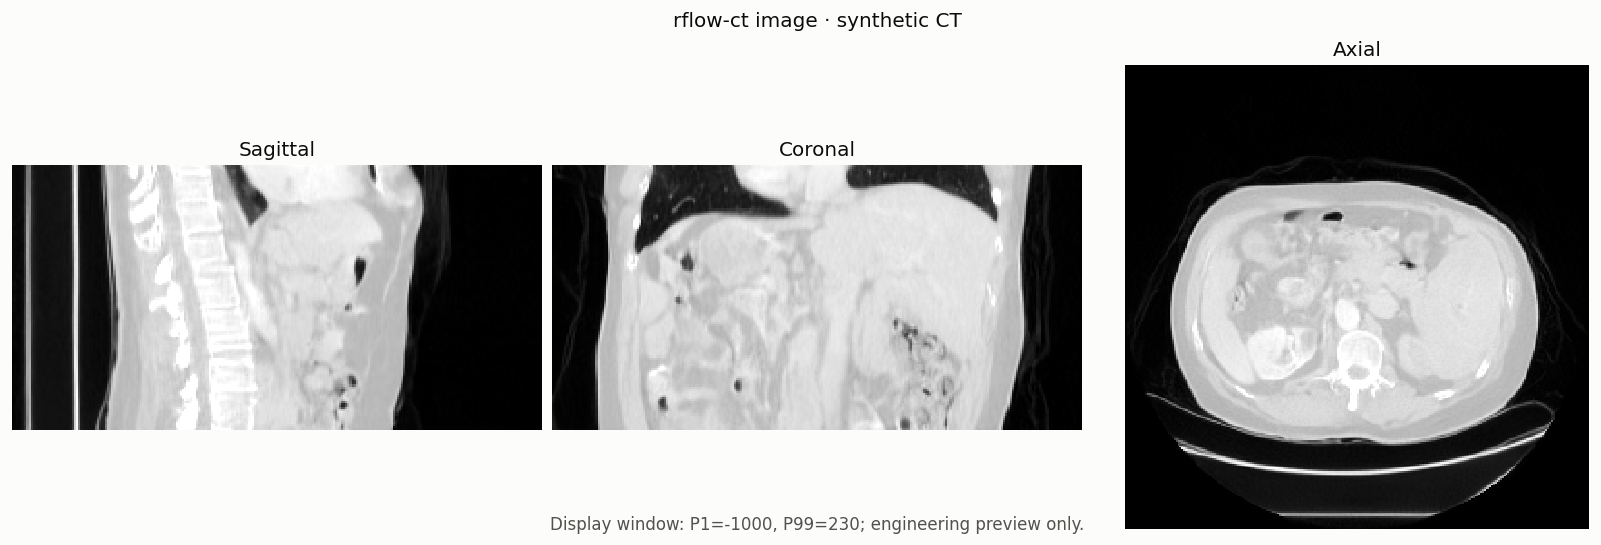

{
  "name": "image",
  "path": "/workspace/output/20260928-034126/image/nv_generate_ct_rflow_image_seed0_size256x256x128_spacing1.70x1.70x2.00_20260928034146_rank0_modality1.nii.gz",
  "bytes": 8735173,
  "sha256": "81b3a4825da97e6c2a6d54ae6cd615a87e089ef7d97aad65f39812361b07c4ff",
  "shape": [
    256,
    256,
    128
  ],
  "spacing_mm": [
    1.7000000476837158,
    1.7000000476837158,
    2.0
  ],
  "orientation": [
    "R",
    "A",
    "S"
  ],
  "affine": [
    [
      1.7000000476837158,
      0.0,
      0.0,
      0.0
    ],
    [
      0.0,
      1.7000000476837158,
      0.0,
      0.0
    ],
    [
      0.0,
      0.0,
      2.0,
      0.0
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  ],
  "dtype": "int16",
  "min": -1000.0,
  "max": 1000.0,
  "checks": {
    "shape_matches": true,
    "spacing_matches": true,
    "affine_finite": true,
    "all_finite": true,
    "nonempty": true,
    "nonconstant": true,
    "contains_negative_values": true,
    "within

In [7]:
IMAGE_NIFTI, IMAGE_VOLUME, IMAGE_REPORT = inspect_nifti(
    "image",
    IMAGE_PATH,
    IMAGE_DIM,
    IMAGE_SPACING,
    "ct",
)
IMAGE_REPORT.update({
    "gpu": GPU_NAME,
    "generation_seconds": IMAGE_SECONDS,
    "peak_allocated_gpu_memory_gib": IMAGE_PEAK_GIB,
    "seed": RANDOM_SEED,
    "inference_steps": IMAGE_STEPS,
})
print("Image runtime:", json.dumps({
    "gpu": GPU_NAME,
    "generation_seconds": IMAGE_SECONDS,
    "peak_allocated_gpu_memory_gib": IMAGE_PEAK_GIB,
}, ensure_ascii=False, indent=2))
plot_ct(IMAGE_VOLUME.astype(np.float32, copy=False), "rflow-ct image · synthetic CT")

### 2.3 `mask`：生成 MAISI label-space 三维标签

`mask` 使用独立的 mask autoencoder、mask diffusion UNet 和 DDPM scheduler。这里的 `1000` 是 mask DDPM 的采样步数，不是上一节 Rectified Flow 的 `30` 步。输出保留完整 MAISI label IDs（包括 body envelope `200`），不做 requested-class-only 过滤。

anatomy-size 值是上游训练条件分布中的相对尺度，不是毫米或精确体积。未显式指定的槽位由上游 anatomy-size 条件数据库中的最近组合补全，因此该列表控制条件，而不是输出类别白名单。

In [8]:
MASK_CONDITIONS = [
    ("liver", 0.5),
    ("hepatic tumor", 0.3),
]
PAIR_CONDITIONS = list(MASK_CONDITIONS)
BODY_REGION = ["abdomen"]

ANATOMY_SIZE_INDEX = {
    "gallbladder": 0,
    "liver": 1,
    "stomach": 2,
    "pancreas": 3,
    "colon": 4,
    "lung tumor": 5,
    "pancreatic tumor": 6,
    "hepatic tumor": 7,
    "colon cancer primaries": 8,
    "bone lesion": 9,
}
TUMOR_NAMES = {
    "lung tumor",
    "pancreatic tumor",
    "hepatic tumor",
    "colon cancer primaries",
    "bone lesion",
}


def prepare_anatomy_size_condition(requested, database_path):
    """按上游 sampler 的 L1 最近条件与显式覆盖规则构造 10 维条件。"""
    if not requested:
        raise ValueError("standalone mask 需要至少一个 controllable anatomy")
    names = [name for name, _ in requested]
    if len(names) != len(set(names)):
        raise ValueError("controllable anatomy 不能重复")
    if sum(name in TUMOR_NAMES for name in names) > 1:
        raise ValueError("上游一次最多支持一个 controllable tumor")

    provided = [None] * 10
    for name, size in requested:
        if name not in ANATOMY_SIZE_INDEX:
            raise ValueError(f"不支持的 controllable anatomy：{name}")
        size = float(size)
        if not (size == -1.0 or 0.0 <= size <= 1.0):
            raise ValueError(f"{name} 的 size 必须位于 [0, 1] 或等于 -1：{size}")
        provided[ANATOMY_SIZE_INDEX[name]] = size

    rows = load_json(database_path)
    if not rows:
        raise ValueError("anatomy-size 条件数据库为空")
    nearest = min(
        rows,
        key=lambda row: sum(
            abs(float(row["organ_size"][index]) - value)
            for index, value in enumerate(provided)
            if value is not None
        ),
    )
    condition = [float(value) for value in nearest["organ_size"]]
    for index, value in enumerate(provided):
        if value is not None:
            condition[index] = value
    if len(condition) != 10:
        raise RuntimeError(f"anatomy-size condition 应为 10 维，实际为 {len(condition)}")
    return condition


LABEL_DICT_PATH = SOURCE_ROOT / "configs/label_dict.json"
LABEL_REMAP_PATH = SOURCE_ROOT / "configs/label_dict_124_to_132.json"
MASK_NETWORK_CONFIG = SOURCE_ROOT / "configs/config_network_rflow.json"

mask_environment = load_json(SOURCE_ROOT / "configs/environment_rflow-ct.json")
mask_environment.update({
    "output_dir": str(MASK_OUTPUT_DIR),
    "trained_mask_generation_autoencoder_path": str(MASK_AUTOENCODER_PATH),
    "trained_mask_generation_diffusion_path": str(MASK_DIFFUSION_PATH),
    "all_anatomy_size_conditions_json": str(ANATOMY_CONDITIONS_PATH),
    "label_dict_json": str(LABEL_DICT_PATH),
    "label_dict_remap_json": str(LABEL_REMAP_PATH),
})
mask_inference = load_json(SOURCE_ROOT / "configs/config_infer.json")
mask_inference.update({
    "controllable_anatomy_size": [list(item) for item in MASK_CONDITIONS],
    "mask_generation_num_inference_steps": MASK_STEPS,
    "output_size": list(MASK_DIM),
    "spacing": list(MASK_SPACING),
})
MASK_ENV_CONFIG = write_json(CONFIG_ROOT / "mask-environment.json", mask_environment)
MASK_INFER_CONFIG = write_json(CONFIG_ROOT / "mask-inference.json", mask_inference)
MASK_PATH = (MASK_OUTPUT_DIR / "nv_generate_ct_rflow_mask.nii.gz").resolve()
MASK_ANATOMY_CONDITION = prepare_anatomy_size_condition(
    MASK_CONDITIONS,
    ANATOMY_CONDITIONS_PATH,
)
print("Mask request:", MASK_CONDITIONS)
print("Mask 10-D anatomy-size condition:", MASK_ANATOMY_CONDITION)

Mask request: [('liver', 0.5), ('hepatic tumor', 0.3)]
Mask 10-D anatomy-size condition: [-1.0, 0.5, 0.486525, 0.287951, 0.278651, -1.0, -1.0, 0.3, -1.0, -1.0]


In [9]:
from monai.utils import set_determinism
from scripts.diff_model_setting import load_config
from scripts.sample_mask import ldm_conditional_sample_one_mask
from scripts.utils_infer import load_mask_models


def generate_standalone_mask():
    set_determinism(seed=RANDOM_SEED)
    cfg = load_config(
        str(MASK_ENV_CONFIG),
        str(MASK_INFER_CONFIG),
        str(MASK_NETWORK_CONFIG),
    )
    mask_autoencoder, mask_unet, mask_scale_factor, mask_scheduler = load_mask_models(
        cfg,
        DEVICE,
    )
    generated = ldm_conditional_sample_one_mask(
        autoencoder=mask_autoencoder,
        diffusion_unet=mask_unet,
        noise_scheduler=mask_scheduler,
        scale_factor=mask_scale_factor,
        anatomy_size=MASK_ANATOMY_CONDITION,
        device=DEVICE,
        latent_shape=tuple(cfg.mask_generation_latent_shape),
        label_dict_remap_json=str(LABEL_REMAP_PATH),
        num_inference_steps=MASK_STEPS,
        autoencoder_sliding_window_infer_size=list(
            cfg.autoencoder_sliding_window_infer_size
        ),
        autoencoder_sliding_window_infer_overlap=(
            cfg.autoencoder_sliding_window_infer_overlap
        ),
    )
    array = generated.squeeze(0).squeeze(0).detach().cpu().numpy()
    rounded = np.rint(array)
    if array.shape != MASK_DIM or not np.isfinite(array).all():
        raise RuntimeError(f"standalone mask shape/finite 异常：{array.shape}")
    if not np.allclose(array, rounded, atol=1e-6, rtol=0):
        raise RuntimeError("standalone mask 含有非整数 label")
    limits = np.iinfo(np.int16)
    if not np.all((rounded >= limits.min) & (rounded <= limits.max)):
        raise RuntimeError("standalone mask label 超出 int16 范围")

    affine = np.diag([*MASK_SPACING, 1.0]).astype(np.float64)
    output = nib.Nifti1Image(rounded.astype(np.int16), affine)
    output.set_data_dtype(np.int16)
    nib.save(output, str(MASK_PATH))

    del generated, mask_autoencoder, mask_unet, mask_scheduler, cfg
    gc.collect()
    torch.cuda.empty_cache()
    return MASK_PATH


MASK_PATH, MASK_SECONDS, MASK_PEAK_GIB = timed_gpu_call(
    "mask",
    generate_standalone_mask,
)
print("Mask NIfTI:", MASK_PATH)

Current model does not support hepatic vessel by size control, so we treat generated hepatic vessel as part of liver for better visiaulization.
mask completed on: MetaX C500
mask end-to-end time (s): 114.707
mask peak allocated GPU memory (GiB): 6.971
Mask NIfTI: /workspace/output/20260928-034126/mask/nv_generate_ct_rflow_mask.nii.gz


100%|##########| 8/8 [00:11<00:00,  1.46s/it]


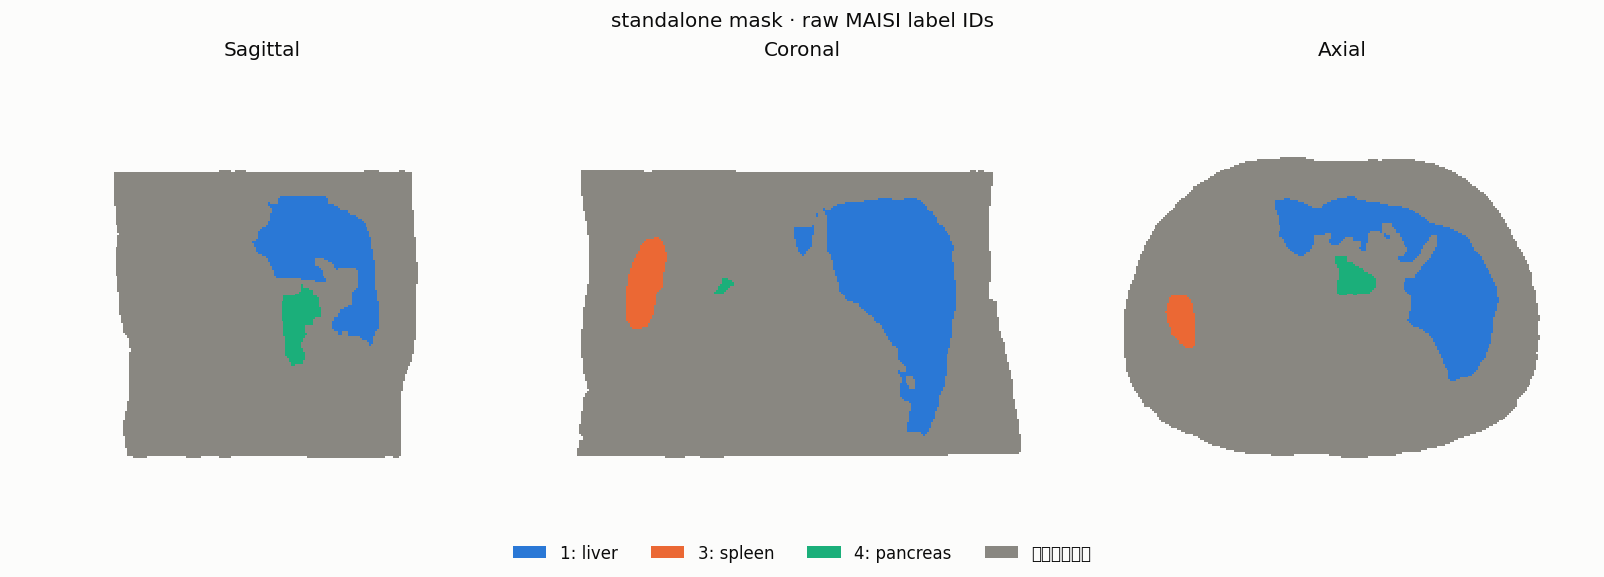

{
  "name": "mask",
  "path": "/workspace/output/20260928-034126/mask/nv_generate_ct_rflow_mask.nii.gz",
  "bytes": 640251,
  "sha256": "d147312787be932c9a004e0d1afa9a71d90d9e766a0366a5808085857ca29e6e",
  "shape": [
    256,
    256,
    256
  ],
  "spacing_mm": [
    1.5,
    1.5,
    1.5
  ],
  "orientation": [
    "R",
    "A",
    "S"
  ],
  "affine": [
    [
      1.5,
      0.0,
      0.0,
      0.0
    ],
    [
      0.0,
      1.5,
      0.0,
      0.0
    ],
    [
      0.0,
      0.0,
      1.5,
      0.0
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  ],
  "dtype": "int16",
  "min": 0.0,
  "max": 200.0,
  "checks": {
    "shape_matches": true,
    "spacing_matches": true,
    "affine_finite": true,
    "all_finite": true,
    "nonempty": true,
    "integer_labels": true,
    "nonnegative_labels": true,
    "has_foreground": true
  },
  "engineering_only": true,
  "clinical_metric": false,
  "label_counts": {
    "0": 12922216,
    "1": 422667,
    "3": 45147

/workspace/run_notebook_headless.py:60: UserWarning: Glyph 20854 (\N{CJK UNIFIED IDEOGRAPH-5176}) missing from font(s) DejaVu Sans.
  figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight", facecolor=figure.get_facecolor())
/workspace/run_notebook_headless.py:60: UserWarning: Glyph 20182 (\N{CJK UNIFIED IDEOGRAPH-4ED6}) missing from font(s) DejaVu Sans.
  figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight", facecolor=figure.get_facecolor())
/workspace/run_notebook_headless.py:60: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight", facecolor=figure.get_facecolor())
/workspace/run_notebook_headless.py:60: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight", facecolor=figure.get_facecolor())
/workspace/run_notebook_headless.py:60: UserWarning: Glyph 2

In [10]:
MASK_NIFTI, MASK_VOLUME, MASK_REPORT = inspect_nifti(
    "mask",
    MASK_PATH,
    MASK_DIM,
    MASK_SPACING,
    "mask",
)
MASK_LABELS = {int(value) for value in np.unique(MASK_VOLUME)}
VALID_MAISI_LABELS = set(range(0, 133)) | {200}
if not MASK_LABELS <= VALID_MAISI_LABELS:
    raise RuntimeError(f"mask 含未知 MAISI IDs：{sorted(MASK_LABELS - VALID_MAISI_LABELS)}")
if 200 not in MASK_LABELS:
    raise RuntimeError("mask 缺少 CT ControlNet 所需的 body envelope label 200")

MAISI_LABEL_NAMES = {
    int(label): name for name, label in load_json(LABEL_DICT_PATH).items()
}
MAISI_LABEL_NAMES[0] = "background"
# 固定上游 remap 将 129 定义为 kidney mass；通用 label_dict 的 dummy6 名称与其不一致。
MAISI_LABEL_NAMES[129] = "kidney mass"
MASK_REPORT.update({
    "gpu": GPU_NAME,
    "generation_seconds": MASK_SECONDS,
    "peak_allocated_gpu_memory_gib": MASK_PEAK_GIB,
    "seed": RANDOM_SEED,
    "inference_steps": MASK_STEPS,
    "label_space": "MAISI IDs",
    "anatomy_size_request": [list(item) for item in MASK_CONDITIONS],
    "anatomy_size_condition": MASK_ANATOMY_CONDITION,
})
print("Mask runtime:", json.dumps({
    "gpu": GPU_NAME,
    "generation_seconds": MASK_SECONDS,
    "peak_allocated_gpu_memory_gib": MASK_PEAK_GIB,
    "labels": sorted(MASK_LABELS),
}, ensure_ascii=False, indent=2))
plot_mask_or_overlay(
    MASK_VOLUME,
    "standalone mask · raw MAISI label IDs",
    MAISI_LABEL_NAMES,
)

### 2.4 `from-mask`：由本轮标签生成三维 CT

本节严格消费上一节刚写入磁盘的 raw MAISI mask，并先检查 3D、finite、整数、label vocabulary、body envelope `200`、RAS orientation、shape 与 spacing。输入已满足发布模型的原生目标，因此上游不会隐式重采样。

模型构造、mask conditioning、ControlNet + Rectified Flow 采样和 autoencoder 解码均直接调用 `scripts.infer_image_from_mask` 与 `scripts.utils_infer` 的公开 Python API。

In [11]:
FROM_MASK_NETWORK_CONFIG = SOURCE_ROOT / "configs/config_network_rflow.json"
from_mask_environment = load_json(SOURCE_ROOT / "configs/environment_rflow-ct.json")
from_mask_environment.update({
    "output_dir": str(FROM_MASK_OUTPUT_DIR),
    "trained_autoencoder_path": str(AUTOENCODER_PATH),
    "trained_diffusion_path": str(DIFFUSION_PATH),
    "trained_controlnet_path": str(CONTROLNET_PATH),
})
from_mask_inference = load_json(SOURCE_ROOT / "configs/config_infer.json")
from_mask_inference.update({
    "num_inference_steps": RFLOW_STEPS,
    "modality": 1,
    "cfg_guidance_scale": MASK_CFG,
})
FROM_MASK_ENV_CONFIG = write_json(
    CONFIG_ROOT / "from-mask-environment.json",
    from_mask_environment,
)
FROM_MASK_INFER_CONFIG = write_json(
    CONFIG_ROOT / "from-mask-inference.json",
    from_mask_inference,
)
FROM_MASK_PATH = (FROM_MASK_OUTPUT_DIR / "nv_generate_ct_rflow_from_mask.nii.gz").resolve()

mask_source_image = nib.load(str(MASK_PATH))
mask_source_array = np.asanyarray(mask_source_image.dataobj)
mask_source_spacing = np.linalg.norm(mask_source_image.affine[:3, :3], axis=0)
mask_source_labels = {int(value) for value in np.unique(mask_source_array)}
if mask_source_array.ndim != 3:
    raise RuntimeError(f"from-mask 输入必须是 scalar 3D：{mask_source_array.shape}")
if not np.isfinite(mask_source_array).all():
    raise RuntimeError("from-mask 输入包含 NaN 或 Inf")
if not np.allclose(mask_source_array, np.rint(mask_source_array), atol=1e-6, rtol=0):
    raise RuntimeError("from-mask 输入必须是整数 label")
if not mask_source_labels <= VALID_MAISI_LABELS:
    raise RuntimeError(f"from-mask 输入含未知 label：{sorted(mask_source_labels - VALID_MAISI_LABELS)}")
if 200 not in mask_source_labels or not (mask_source_labels - {0}):
    raise RuntimeError("from-mask 输入必须同时包含前景和 body envelope 200")
if tuple(mask_source_array.shape) != MASK_DIM:
    raise RuntimeError(f"from-mask 输入 shape 不符合无重采样合约：{mask_source_array.shape}")
if not np.allclose(mask_source_spacing, MASK_SPACING, atol=1e-6, rtol=0):
    raise RuntimeError(f"from-mask 输入 spacing 不符合无重采样合约：{mask_source_spacing}")
if nib.aff2axcodes(mask_source_image.affine) != ("R", "A", "S"):
    raise RuntimeError("from-mask 输入必须预先是 RAS orientation")
print("Conditioning mask SHA-256:", sha256_file(MASK_PATH))

Conditioning mask SHA-256: d147312787be932c9a004e0d1afa9a71d90d9e766a0366a5808085857ca29e6e


In [12]:
from scripts.infer_image_from_mask import (
    ldm_conditional_sample_one_image_from_mask,
    validate_user_mask,
)
from scripts.utils_infer import build_conditioning_tensors, load_image_models


def generate_image_from_mask():
    set_determinism(seed=RANDOM_SEED)
    mask_info = validate_user_mask(str(MASK_PATH))
    if tuple(mask_info["shape"]) != MASK_DIM:
        raise RuntimeError("上游意外改变了 conditioning mask shape")
    if not np.allclose(mask_info["spacing"], MASK_SPACING, atol=1e-6, rtol=0):
        raise RuntimeError("上游意外改变了 conditioning mask spacing")

    cfg = load_config(
        str(FROM_MASK_ENV_CONFIG),
        str(FROM_MASK_INFER_CONFIG),
        str(FROM_MASK_NETWORK_CONFIG),
    )
    autoencoder, diffusion_unet, controlnet, scale_factor, scheduler = (
        load_image_models(cfg, DEVICE)
    )
    label = mask_info["label"].to(DEVICE)
    spacing_tensor, top_tensor, bottom_tensor, modality_tensor = (
        build_conditioning_tensors(
            label,
            mask_info["spacing"],
            int(cfg.modality),
            diffusion_unet.include_top_region_index_input,
            DEVICE,
        )
    )
    latent_shape = (
        int(cfg.latent_channels),
        *(dimension // 4 for dimension in mask_info["shape"]),
    )
    synthetic, returned_label = ldm_conditional_sample_one_image_from_mask(
        autoencoder=autoencoder,
        diffusion_unet=diffusion_unet,
        controlnet=controlnet,
        noise_scheduler=scheduler,
        scale_factor=scale_factor,
        device=DEVICE,
        combine_label_or=label,
        spacing_tensor=spacing_tensor,
        latent_shape=latent_shape,
        output_size=mask_info["shape"],
        noise_factor=1.0,
        top_region_index_tensor=top_tensor,
        bottom_region_index_tensor=bottom_tensor,
        modality_tensor=modality_tensor,
        num_inference_steps=RFLOW_STEPS,
        autoencoder_sliding_window_infer_size=(
            cfg.autoencoder_sliding_window_infer_size
        ),
        autoencoder_sliding_window_infer_overlap=(
            cfg.autoencoder_sliding_window_infer_overlap
        ),
        cfg_guidance_scale=float(cfg.cfg_guidance_scale),
    )
    array = synthetic.squeeze(0).squeeze(0).detach().cpu().numpy()
    if array.shape != MASK_DIM or not np.isfinite(array).all():
        raise RuntimeError(f"from-mask CT shape/finite 异常：{array.shape}")
    output = nib.Nifti1Image(
        array.astype(np.float32, copy=False),
        np.asarray(mask_source_image.affine, dtype=np.float64),
    )
    output.set_data_dtype(np.float32)
    nib.save(output, str(FROM_MASK_PATH))

    del synthetic, returned_label, label, autoencoder, diffusion_unet, controlnet
    del scheduler, cfg, mask_info
    gc.collect()
    torch.cuda.empty_cache()
    return FROM_MASK_PATH


FROM_MASK_PATH, FROM_MASK_SECONDS, FROM_MASK_PEAK_GIB = timed_gpu_call(
    "from-mask",
    generate_image_from_mask,
)
print("From-mask CT NIfTI:", FROM_MASK_PATH)

from-mask completed on: MetaX C500
from-mask end-to-end time (s): 16.122
from-mask peak allocated GPU memory (GiB): 9.253
From-mask CT NIfTI: /workspace/output/20260928-034126/from-mask/nv_generate_ct_rflow_from_mask.nii.gz


[validate] loaded nv_generate_ct_rflow_mask.nii.gz: shape=(256, 256, 256), spacing=(1.5, 1.5, 1.5)
[validate] ✓ all 72 unique label values are in the MAISI 132-class vocabulary.
[validate] ✓ shape + spacing already match a valid target — no resample needed.
100%|##########| 8/8 [00:05<00:00,  1.37it/s]


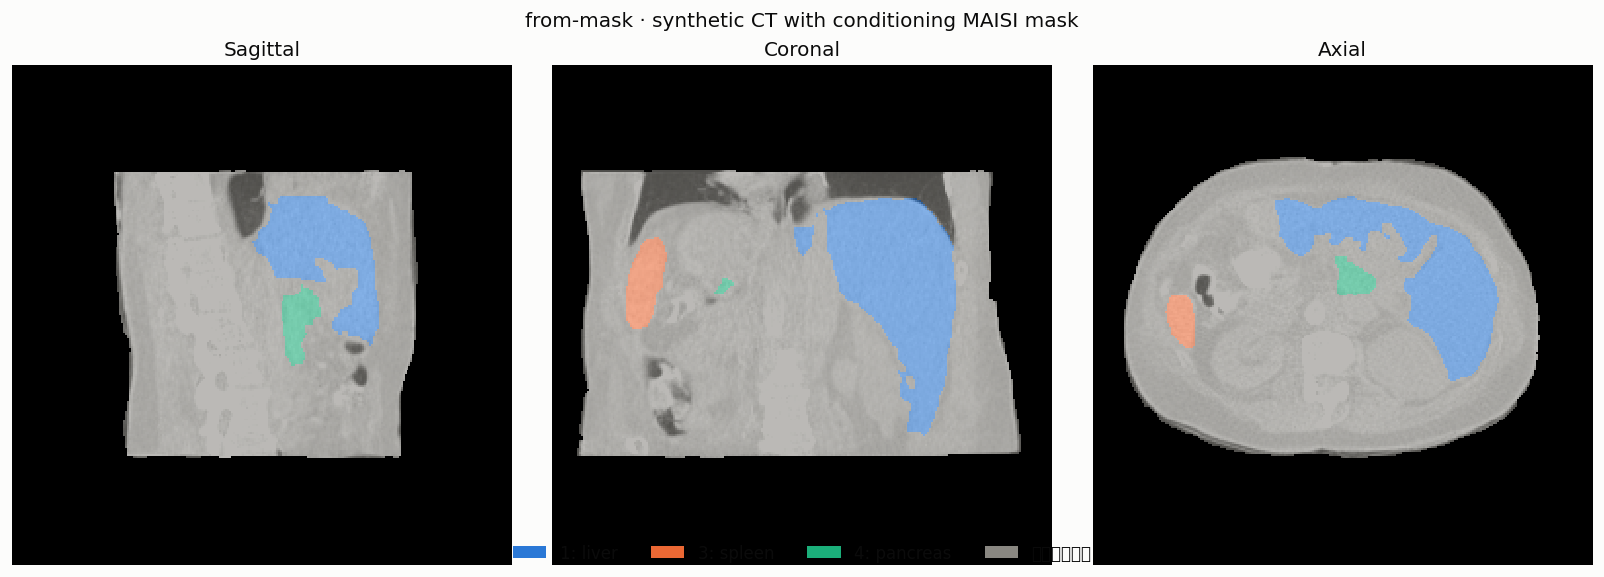

{
  "name": "from-mask",
  "path": "/workspace/output/20260928-034126/from-mask/nv_generate_ct_rflow_from_mask.nii.gz",
  "bytes": 7661383,
  "sha256": "0de9ee9122e29a58a892f26d8598c877ef72c65ef7a559b8f361de57e73856b2",
  "shape": [
    256,
    256,
    256
  ],
  "spacing_mm": [
    1.5,
    1.5,
    1.5
  ],
  "orientation": [
    "R",
    "A",
    "S"
  ],
  "affine": [
    [
      1.5,
      0.0,
      0.0,
      0.0
    ],
    [
      0.0,
      1.5,
      0.0,
      0.0
    ],
    [
      0.0,
      0.0,
      1.5,
      0.0
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  ],
  "dtype": "float32",
  "min": -1000.0,
  "max": 1000.0,
  "checks": {
    "shape_matches": true,
    "spacing_matches": true,
    "affine_finite": true,
    "all_finite": true,
    "nonempty": true,
    "affine_matches_reference": true,
    "nonconstant": true,
    "contains_negative_values": true,
    "within_upstream_mapping": true
  },
  "engineering_only": true,
  "clinical_metric": fals

/workspace/run_notebook_headless.py:60: UserWarning: Glyph 20854 (\N{CJK UNIFIED IDEOGRAPH-5176}) missing from font(s) DejaVu Sans.
  figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight", facecolor=figure.get_facecolor())
/workspace/run_notebook_headless.py:60: UserWarning: Glyph 20182 (\N{CJK UNIFIED IDEOGRAPH-4ED6}) missing from font(s) DejaVu Sans.
  figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight", facecolor=figure.get_facecolor())
/workspace/run_notebook_headless.py:60: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight", facecolor=figure.get_facecolor())
/workspace/run_notebook_headless.py:60: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight", facecolor=figure.get_facecolor())
/workspace/run_notebook_headless.py:60: UserWarning: Glyph 2

In [13]:
FROM_MASK_NIFTI, FROM_MASK_VOLUME, FROM_MASK_REPORT = inspect_nifti(
    "from-mask",
    FROM_MASK_PATH,
    MASK_DIM,
    MASK_SPACING,
    "ct",
    reference_affine=MASK_NIFTI.affine,
)
FROM_MASK_REPORT.update({
    "gpu": GPU_NAME,
    "generation_seconds": FROM_MASK_SECONDS,
    "peak_allocated_gpu_memory_gib": FROM_MASK_PEAK_GIB,
    "seed": RANDOM_SEED,
    "inference_steps": RFLOW_STEPS,
    "conditioning_mask_path": str(MASK_PATH),
    "conditioning_mask_sha256": sha256_file(MASK_PATH),
})
print("From-mask runtime:", json.dumps({
    "gpu": GPU_NAME,
    "generation_seconds": FROM_MASK_SECONDS,
    "peak_allocated_gpu_memory_gib": FROM_MASK_PEAK_GIB,
    "conditioning_mask_sha256": FROM_MASK_REPORT["conditioning_mask_sha256"],
}, ensure_ascii=False, indent=2))
plot_mask_or_overlay(
    MASK_VOLUME,
    "from-mask · synthetic CT with conditioning MAISI mask",
    MAISI_LABEL_NAMES,
    ct=FROM_MASK_VOLUME.astype(np.float32, copy=False),
)

### 2.5 `pair`：生成空间配对的 CT 与局部 ordinal label

本节直接调用 `LDMSampler` 的 nonempty `controllable_anatomy_size` 分支。candidate-mask JSON 和目录显式设为 `None`，不调用上游下载器，也不扫描 candidate-mask 数据集。

保存的 label 只保留请求 anatomy，并按请求顺序编号：`1 = liver`、`2 = hepatic tumor`。它不是 raw MAISI mask，不能直接作为上一节发布 ControlNet 的输入。某一请求 anatomy 若本轮没有保留下来，对应 ordinal 可以缺失，后续 ordinal 不会重排。

In [14]:
PAIR_NETWORK_CONFIG = SOURCE_ROOT / "configs/config_network_rflow.json"
PAIR_LABEL_NAMES = {
    index: anatomy for index, (anatomy, _) in enumerate(PAIR_CONDITIONS, start=1)
}
pair_environment = load_json(SOURCE_ROOT / "configs/environment_rflow-ct.json")
pair_environment.update({
    "output_dir": str(PAIR_OUTPUT_DIR),
    "trained_autoencoder_path": str(AUTOENCODER_PATH),
    "trained_diffusion_path": str(DIFFUSION_PATH),
    "trained_controlnet_path": str(CONTROLNET_PATH),
    "trained_mask_generation_autoencoder_path": str(MASK_AUTOENCODER_PATH),
    "trained_mask_generation_diffusion_path": str(MASK_DIFFUSION_PATH),
    "all_mask_files_base_dir": None,
    "all_mask_files_json": None,
    "all_anatomy_size_conditions_json": str(ANATOMY_CONDITIONS_PATH),
    "label_dict_json": str(LABEL_DICT_PATH),
    "label_dict_remap_json": str(LABEL_REMAP_PATH),
})
pair_inference = load_json(SOURCE_ROOT / "configs/config_infer.json")
pair_inference.update({
    "num_output_samples": 1,
    "body_region": BODY_REGION,
    "anatomy_list": [name for name, _ in PAIR_CONDITIONS],
    "controllable_anatomy_size": [list(item) for item in PAIR_CONDITIONS],
    "num_inference_steps": RFLOW_STEPS,
    "mask_generation_num_inference_steps": MASK_STEPS,
    "output_size": list(MASK_DIM),
    "spacing": list(MASK_SPACING),
    "modality": 1,
    "cfg_guidance_scale": MASK_CFG,
})
PAIR_ENV_CONFIG = write_json(CONFIG_ROOT / "pair-environment.json", pair_environment)
PAIR_INFER_CONFIG = write_json(CONFIG_ROOT / "pair-inference.json", pair_inference)
PAIR_MAPPING_PATH = write_json(
    PAIR_OUTPUT_DIR / "ordinal-label-map.json",
    {
        "label_space": "local ordinal",
        "mapping": {str(index): name for index, name in PAIR_LABEL_NAMES.items()},
        "controllable_anatomy_size": [list(item) for item in PAIR_CONDITIONS],
    },
)
print("Pair ordinal mapping:", PAIR_LABEL_NAMES)
print("Pair mapping sidecar:", PAIR_MAPPING_PATH)

Pair ordinal mapping: {1: 'liver', 2: 'hepatic tumor'}
Pair mapping sidecar: /workspace/output/20260928-034126/pair/ordinal-label-map.json


In [15]:
from scripts.sample import LDMSampler, check_input_ct
from scripts.utils_infer import load_paired_inference_models


def generate_controllable_pair():
    set_determinism(seed=RANDOM_SEED)
    cfg = load_config(
        str(PAIR_ENV_CONFIG),
        str(PAIR_INFER_CONFIG),
        str(PAIR_NETWORK_CONFIG),
    )
    check_input_ct(
        cfg.body_region,
        cfg.anatomy_list,
        cfg.label_dict_json,
        cfg.output_size,
        cfg.spacing,
        cfg.controllable_anatomy_size,
    )
    if cfg.all_mask_files_json is not None or cfg.all_mask_files_base_dir is not None:
        raise RuntimeError("pair 必须保持 candidate-mask 引用为 None")
    model_bundle = load_paired_inference_models(cfg, DEVICE)
    latent_shape = [
        int(cfg.latent_channels),
        *(int(dimension) // 4 for dimension in cfg.output_size),
    ]
    sampler = LDMSampler(
        body_region=cfg.body_region,
        anatomy_list=cfg.anatomy_list,
        all_mask_files_json=None,
        all_anatomy_size_conditions_json=cfg.all_anatomy_size_conditions_json,
        all_mask_files_base_dir=None,
        label_dict_json=cfg.label_dict_json,
        label_dict_remap_json=cfg.label_dict_remap_json,
        device=DEVICE,
        latent_shape=latent_shape,
        mask_generation_latent_shape=cfg.mask_generation_latent_shape,
        output_size=cfg.output_size,
        output_dir=cfg.output_dir,
        controllable_anatomy_size=cfg.controllable_anatomy_size,
        image_output_ext=cfg.image_output_ext,
        label_output_ext=cfg.label_output_ext,
        real_img_median_statistics=str(
            SOURCE_ROOT / "configs/image_median_statistics_ct.json"
        ),
        spacing=cfg.spacing,
        modality=cfg.modality,
        num_inference_steps=cfg.num_inference_steps,
        mask_generation_num_inference_steps=(
            cfg.mask_generation_num_inference_steps
        ),
        random_seed=RANDOM_SEED,
        autoencoder_sliding_window_infer_size=(
            cfg.autoencoder_sliding_window_infer_size
        ),
        autoencoder_sliding_window_infer_overlap=(
            cfg.autoencoder_sliding_window_infer_overlap
        ),
        cfg_guidance_scale=cfg.cfg_guidance_scale,
        **model_bundle,
    )
    generated = sampler.sample_multiple_images(int(cfg.num_output_samples))
    if len(generated) != 1 or len(generated[0]) != 2:
        raise RuntimeError(f"pair 预期返回一个 CT/label 对，实际为：{generated}")
    image_path, label_path = (Path(path).resolve() for path in generated[0])
    del sampler, model_bundle, cfg
    gc.collect()
    torch.cuda.empty_cache()
    return image_path, label_path


pair_paths, PAIR_SECONDS, PAIR_PEAK_GIB = timed_gpu_call(
    "pair",
    generate_controllable_pair,
)
PAIR_IMAGE_PATH, PAIR_LABEL_PATH = pair_paths
if PAIR_IMAGE_PATH.parent != PAIR_OUTPUT_DIR or PAIR_LABEL_PATH.parent != PAIR_OUTPUT_DIR:
    raise RuntimeError(f"pair 输出不在本次目录：{pair_paths}")
print("Pair CT NIfTI:", PAIR_IMAGE_PATH)
print("Pair label NIfTI:", PAIR_LABEL_PATH)

Current model does not support hepatic vessel by size control, so we treat generated hepatic vessel as part of liver for better visiaulization.
pair completed on: MetaX C500
pair end-to-end time (s): 123.974
pair peak allocated GPU memory (GiB): 10.016
Pair CT NIfTI: /workspace/output/20260928-034126/pair/sample_20260928_034614_338936_image.nii.gz
Pair label NIfTI: /workspace/output/20260928-034126/pair/sample_20260928_034614_338936_label.nii.gz


100%|##########| 8/8 [00:05<00:00,  1.36it/s]


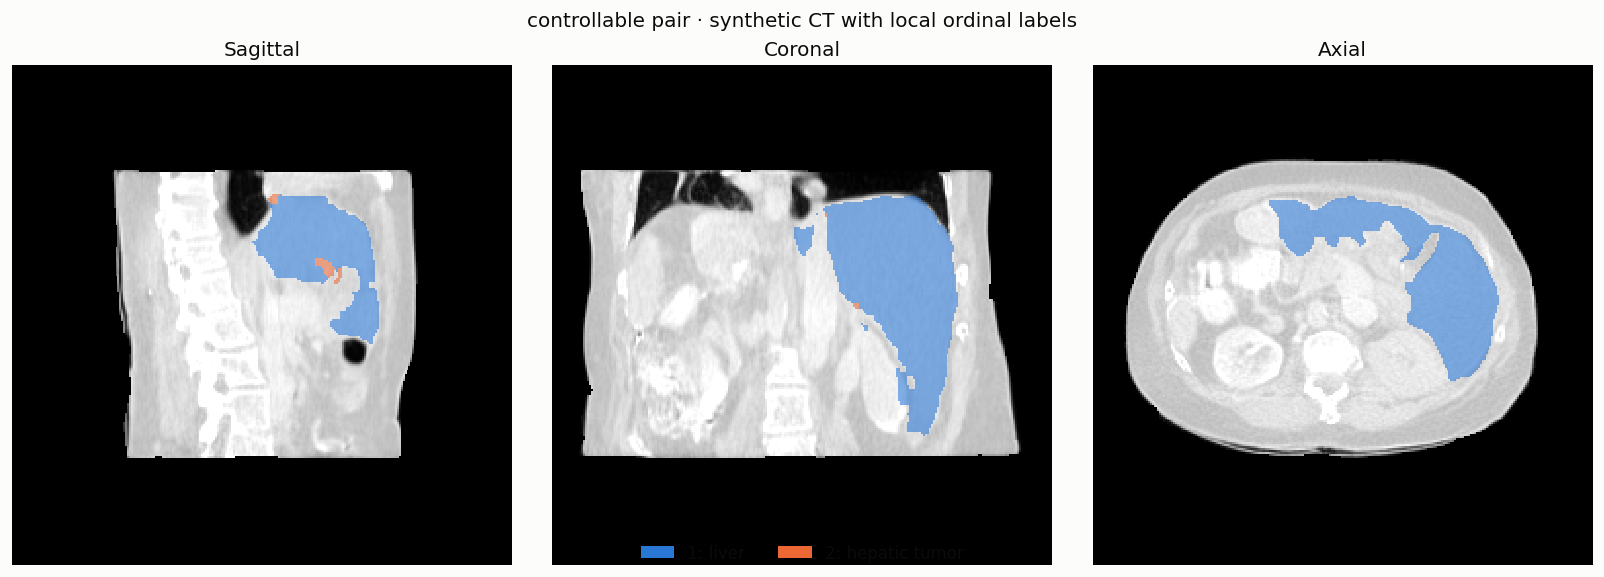

{
  "name": "pair image",
  "path": "/workspace/output/20260928-034126/pair/sample_20260928_034614_338936_image.nii.gz",
  "bytes": 7567180,
  "sha256": "4ed6a75f347609611fa971d76eabc1a8bd2f582c4c5a2576e0833103e480a53e",
  "shape": [
    256,
    256,
    256
  ],
  "spacing_mm": [
    1.5,
    1.5,
    1.5
  ],
  "orientation": [
    "R",
    "A",
    "S"
  ],
  "affine": [
    [
      1.5,
      0.0,
      0.0,
      0.0
    ],
    [
      0.0,
      1.5,
      0.0,
      0.0
    ],
    [
      0.0,
      0.0,
      1.5,
      0.0
    ],
    [
      0.0,
      0.0,
      0.0,
      1.0
    ]
  ],
  "dtype": "float32",
  "min": -1000.0,
  "max": 1000.0,
  "checks": {
    "shape_matches": true,
    "spacing_matches": true,
    "affine_finite": true,
    "all_finite": true,
    "nonempty": true,
    "nonconstant": true,
    "contains_negative_values": true,
    "within_upstream_mapping": true
  },
  "engineering_only": true,
  "clinical_metric": false,
  "mean": -782.5179443359375,
  "s

In [16]:
PAIR_IMAGE_NIFTI, PAIR_IMAGE_VOLUME, PAIR_IMAGE_REPORT = inspect_nifti(
    "pair image",
    PAIR_IMAGE_PATH,
    MASK_DIM,
    MASK_SPACING,
    "ct",
)
PAIR_LABEL_NIFTI, PAIR_LABEL_VOLUME, PAIR_LABEL_REPORT = inspect_nifti(
    "pair label",
    PAIR_LABEL_PATH,
    MASK_DIM,
    MASK_SPACING,
    "mask",
    reference_affine=PAIR_IMAGE_NIFTI.affine,
)
pair_labels = {int(value) for value in np.unique(PAIR_LABEL_VOLUME)}
allowed_pair_labels = {0, *PAIR_LABEL_NAMES.keys()}
if not pair_labels <= allowed_pair_labels:
    raise RuntimeError(
        f"pair label 超出本次局部 ordinal 空间：{sorted(pair_labels - allowed_pair_labels)}"
    )
PAIR_IMAGE_REPORT.update({
    "gpu": GPU_NAME,
    "generation_seconds": PAIR_SECONDS,
    "peak_allocated_gpu_memory_gib": PAIR_PEAK_GIB,
    "seed": RANDOM_SEED,
    "image_inference_steps": RFLOW_STEPS,
    "mask_inference_steps": MASK_STEPS,
})
PAIR_LABEL_REPORT.update({
    "label_space": "local ordinal",
    "ordinal_mapping": {str(index): name for index, name in PAIR_LABEL_NAMES.items()},
    "mapping_sidecar": str(PAIR_MAPPING_PATH),
})
print("Pair runtime:", json.dumps({
    "gpu": GPU_NAME,
    "generation_seconds": PAIR_SECONDS,
    "peak_allocated_gpu_memory_gib": PAIR_PEAK_GIB,
    "ordinal_mapping": PAIR_LABEL_REPORT["ordinal_mapping"],
    "labels_present": sorted(pair_labels),
}, ensure_ascii=False, indent=2))
plot_mask_or_overlay(
    PAIR_LABEL_VOLUME,
    "controllable pair · synthetic CT with local ordinal labels",
    PAIR_LABEL_NAMES,
    ct=PAIR_IMAGE_VOLUME.astype(np.float32, copy=False),
)

### 2.6 结果说明

- 四类显示内容均来自本 Notebook 同一次完整运行，不是患者影像，也不是历史结果。
- `image` 与 `from-mask` 输出是模型生成的 synthetic CT；`mask` 与 `pair` label map 是模型生成或推理管线产生的条件/配对标签。
- shape、spacing、affine、finite、nonconstant、label vocabulary、运行耗时、显存和切片预览属于工程检查，不代表解剖真实性、医学质量、临床有效性、去标识化或监管合规性。
- 本教程直接调用上游公开入口；没有依赖 `hpc_medical_skills` wrapper、fixture、helper 或目标目录外的自定义脚本。

---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.